In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#set style
sns.set_style(style='whitegrid')

In [ ]:
!git clone https://github.com/HarshvardhanSingh-13/Datasets

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 26.52 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [ ]:
df=pd.read_csv('/content/Datasets/Titanic_Dataset/Titanic-Dataset.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.shape

(891, 12)

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Insights drawn from the above description
>About 38.4% of the passengers survived
>The age range in this dataset is from around 5 months-80years
>average age of the passengers is 30 years
>Fare is highly right skewed,as the average fare is around 32 whereas median is just 14.45
and maximum fare is 512$ which indicates the presence of extreme outliers


In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
median_age=df['Age'].median()

In [ ]:
df['Age']=df['Age'].fillna(median_age)

In [ ]:
mode_embarked=df['Embarked'].mode()[0]

In [ ]:
df['Embarked']=df['Embarked'].fillna(mode_embarked)

In [ ]:
df['Cabin'].notna()

,Cabin
0,False
1,True
2,False
3,True
4,False
...,...
886,False
887,True
888,False
889,True


In [ ]:
df['Has_Cabin']=df['Cabin'].notna().astype(int)

In [ ]:
df.drop('Cabin',axis=1,inplace=True)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


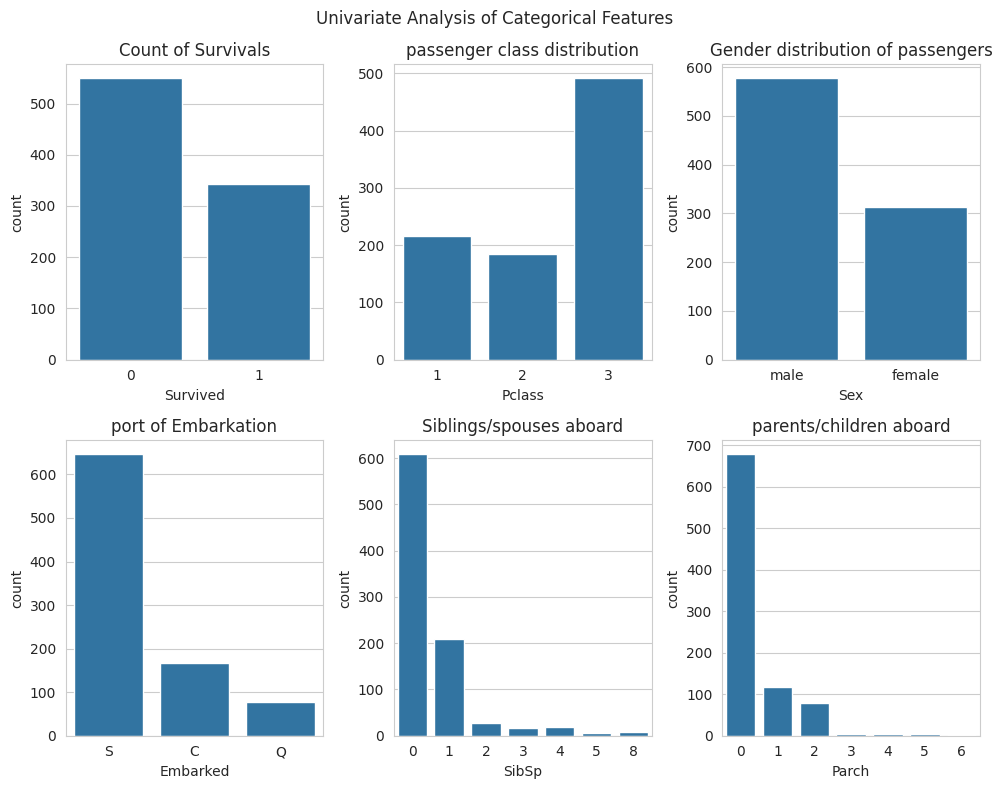

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(10,8))
plt.suptitle('Univariate Analysis of Categorical Features')

sns.countplot(x='Survived',data=df,ax=axes[0,0])
axes[0,0].set_title('Count of Survivals')

sns.countplot(x='Pclass',data=df,ax=axes[0,1])
axes[0,1].set_title('passenger class distribution')

sns.countplot(x='Sex',data=df,ax=axes[0,2])
axes[0,2].set_title('Gender distribution of passengers')

sns.countplot(x='Embarked',data=df,ax=axes[1,0])
axes[1,0].set_title('port of Embarkation')

sns.countplot(x='SibSp',data=df,ax=axes[1,1])
axes[1,1].set_title('Siblings/spouses aboard')

sns.countplot(x='Parch',data=df,ax=axes[1,2])
axes[1,2].set_title('parents/children aboard')

plt.tight_layout()
plt.show()





key insights from univariate analysis
>most passengers did not survive(over 500 passengers),
>passengers were highly populated in the third class,
>population of male passengers is significantly higher than female passengers,
>Most passengers boarded the titanic from Southampton (England) port,
>Most of the passengers travelled solo.


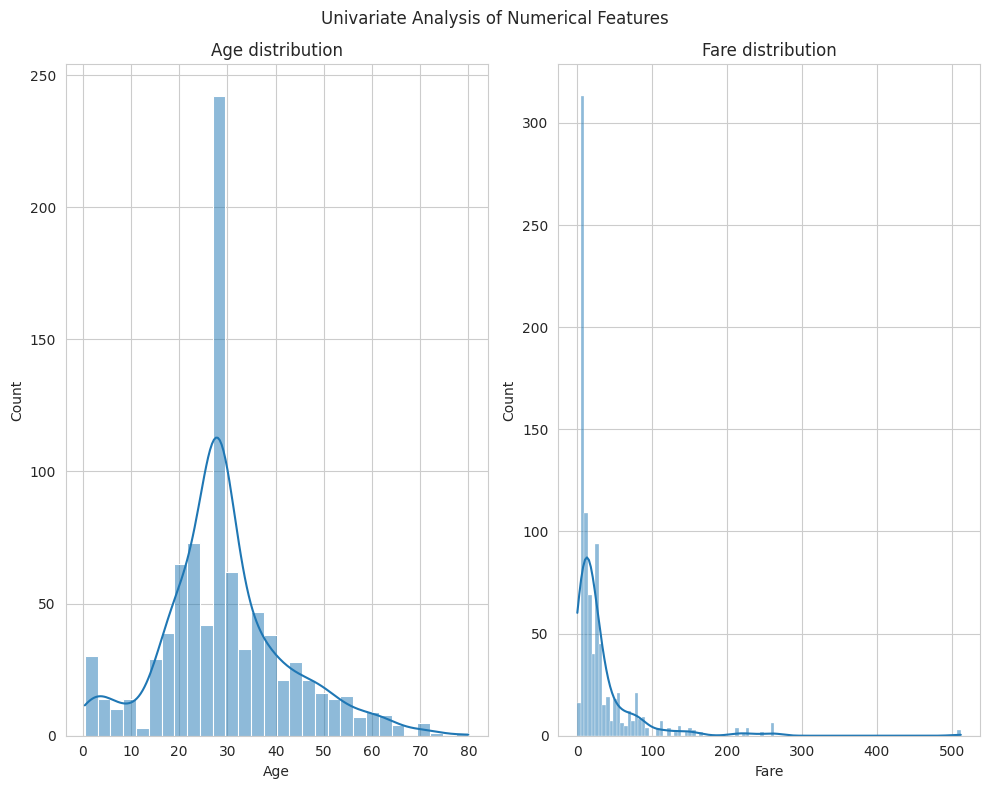

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,8))
plt.suptitle('Univariate Analysis of Numerical Features')

sns.histplot(x='Age',data=df,ax=axes[0],kde=True)
axes[0].set_title('Age distribution')

sns.histplot(x='Fare',data=df,ax=axes[1],kde=True).set_title('Fare distribution')

plt.tight_layout()
plt.show()


key insights
>The age distribution peaks for the range 20-30,
point to note-imputation of median significantly impacted the height of the central bar,
>fare distribution is heavily right skewed implying that most tickets were cheap with very few expensive ones

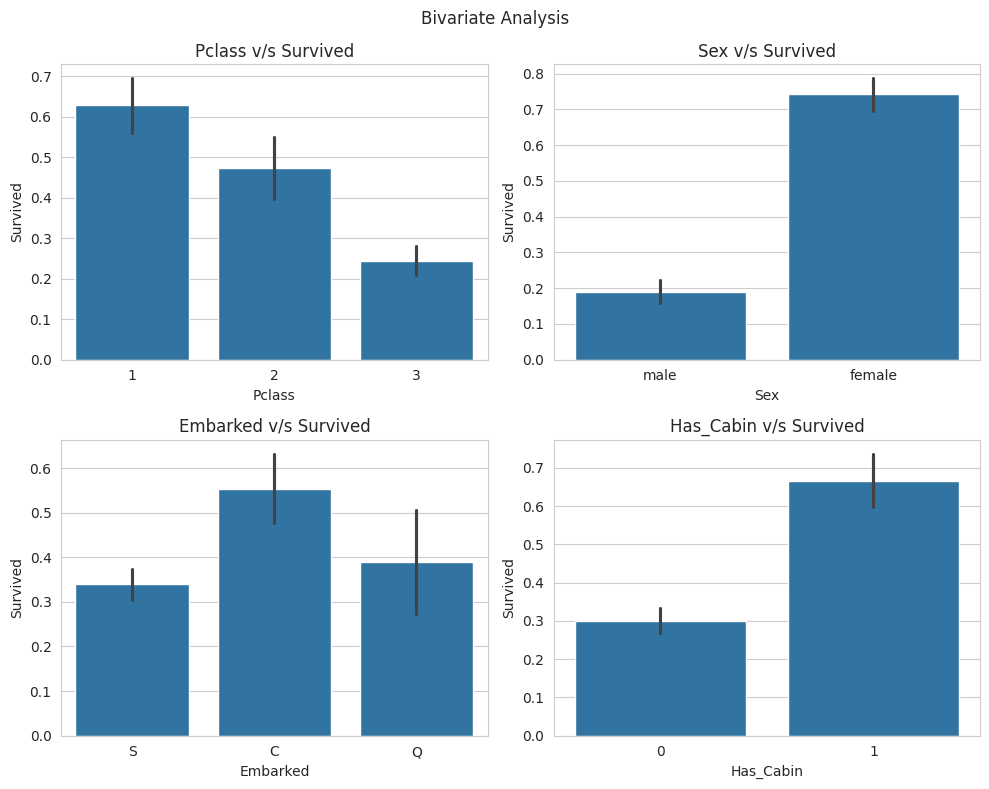

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(10,8))
plt.suptitle('Bivariate Analysis')

sns.barplot(ax=axes[0,0],data=df,x='Pclass',y='Survived').set_title('Pclass v/s Survived')
sns.barplot(ax=axes[0,1],data=df,x='Sex',y='Survived').set_title('Sex v/s Survived')
sns.barplot(ax=axes[1,0],data=df,x='Embarked',y='Survived').set_title('Embarked v/s Survived')
sns.barplot(ax=axes[1,1],data=df,x='Has_Cabin',y='Survived').set_title('Has_Cabin v/s Survived')

plt.tight_layout()
plt.show()


key insights
>first class passengers had a survival rate of more than 60%,while the third passenger class had less than 30% survival rate.
>females had a survival rate of more than 70% while males had a survival rate less than 20%
>The survival rate is the highest for passengers who boarded from Southampton (England) than other ports ,which is more than 50%
>Passengers with a cabin had higher survival rate when compared to those who did not have a cabin allotted,This is very much correlated with first class passengers.



<Figure size 640x480 with 0 Axes>

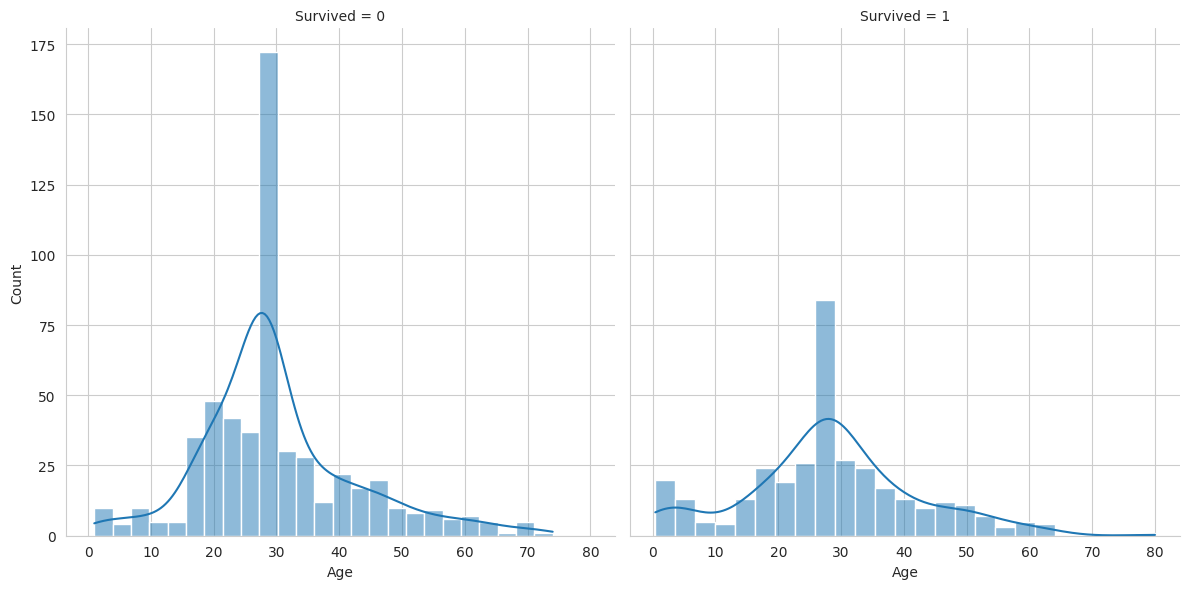

In [ ]:

plt.suptitle("Age distribution by survival status")

g=sns.FacetGrid(data=df,col='Survived',height=6)
g.map(sns.histplot,'Age',bins=25,kde=True)
plt.tight_layout()
plt.show()


Key Insights
>Infants and young children had higher probability of survival,Most of the non-Survivors were young adults and oldest passenger(80 years) did not survive.

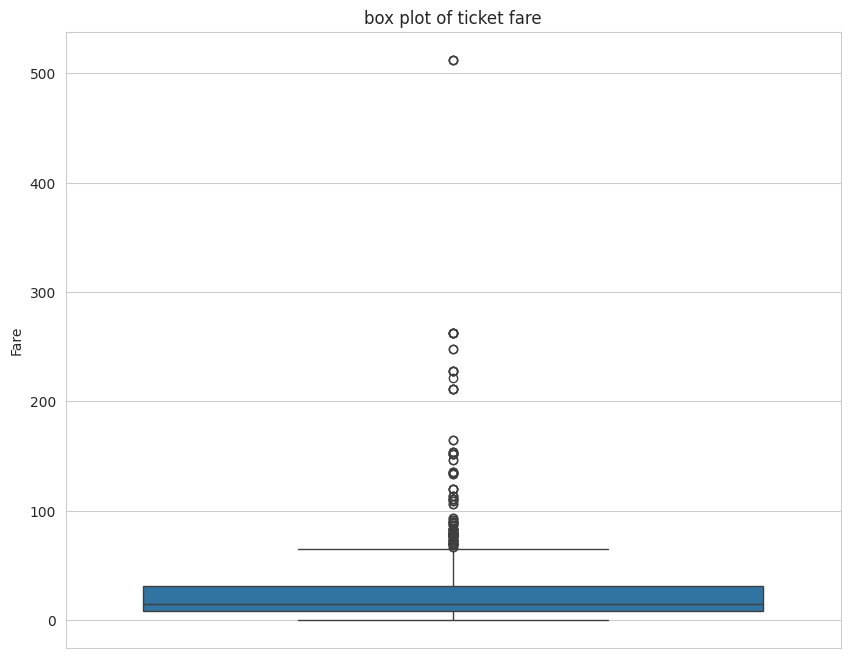

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(y='Fare',data=df)
plt.title('box plot of ticket fare')
plt.ylabel('Fare')
plt.show()


Key Insights
>Most fares are below $100,also there are several other fares extending beyond $100 and some exceeding beyond $500 and these are likely to be first class passengers who booked luxurious suites

In [ ]:
#creating a new feature
df['FamilySize']=df['SibSp']+df['Parch']+1

#IsAlone feature
df['IsAlone']=0
df.loc[df['FamilySize']==1,'IsAlone']=1

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1


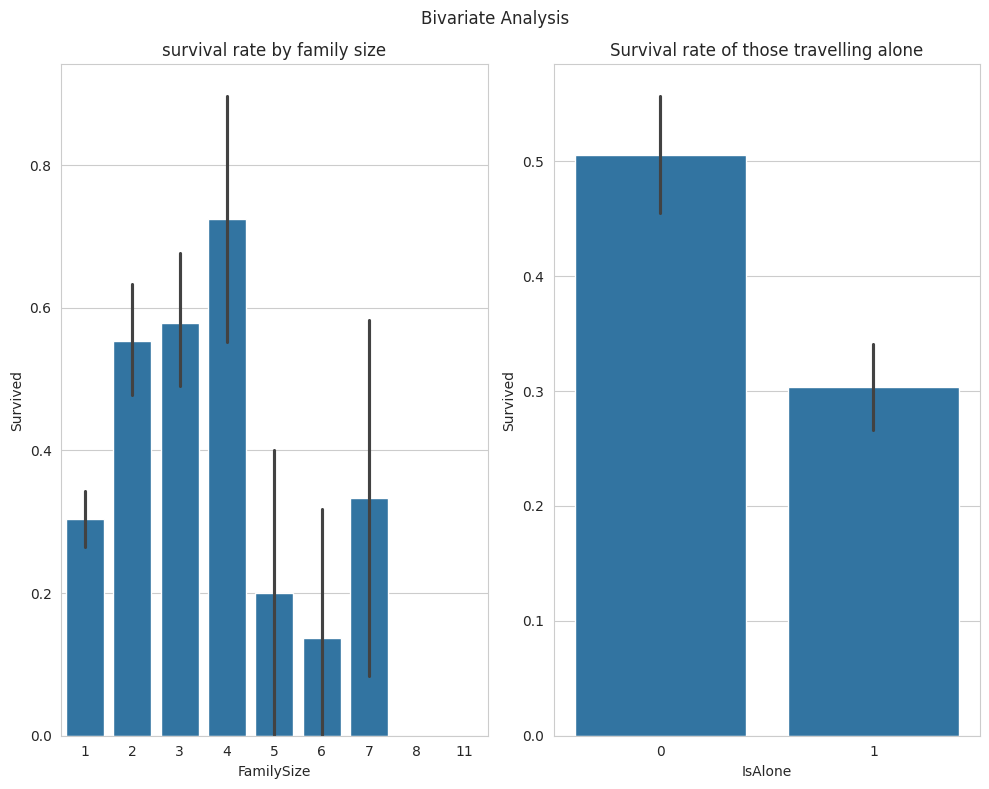

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,8))
plt.suptitle('Bivariate Analysis')

sns.barplot(ax=axes[0],data=df,y='Survived',x='FamilySize').set_title('survival rate by family size')

sns.barplot(ax=axes[1],data=df,y='Survived',x='IsAlone').set_title('Survival rate of those travelling alone')
plt.tight_layout()
plt.show()

key insights
>Passengers who were alone had lower survival rate than those in small families,Small families of 2-4 had higher survival rate but large families(more than 5) had lower survival rate.It might be because it was harder for them to stay together and evacuate

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1


In [ ]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
df['Title'].value_counts()


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
df['Title']=df['Title'].replace(['Ms','Mlle'],'Miss')
df['Title']=df['Title'].replace('Mme','Mrs')
df['Title']=df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona','the Countess'],'Rare')

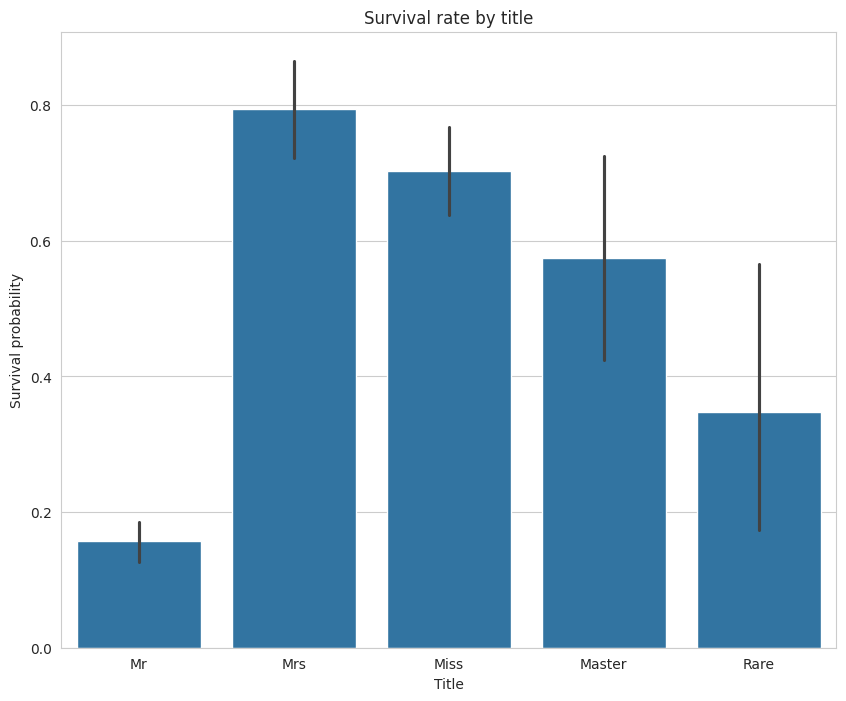

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x='Title',y='Survived',data=df)
plt.title('Survival rate by title')
plt.ylabel('Survival probability')
plt.xlabel('Title')
plt.show()

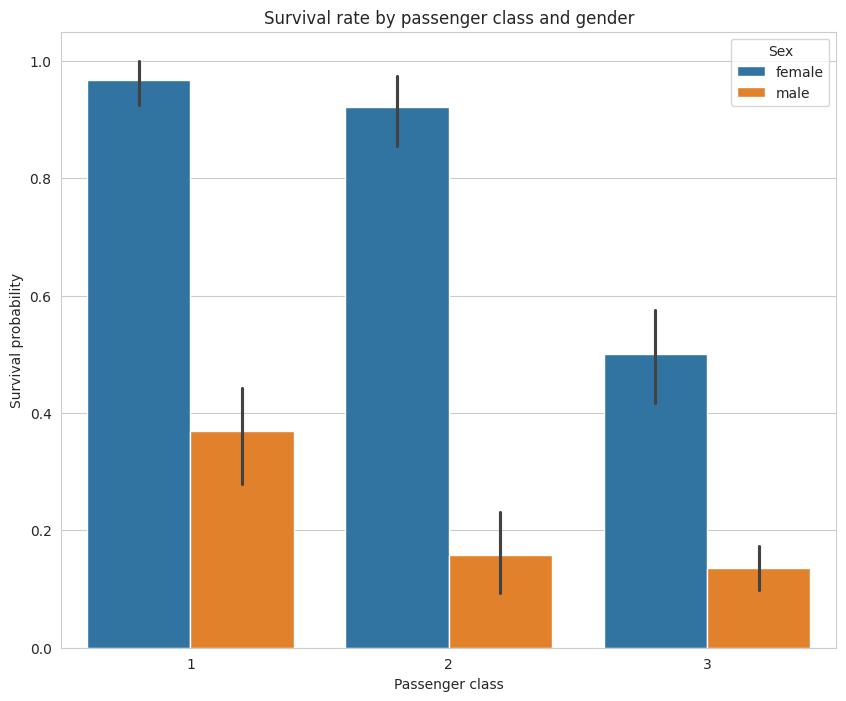

In [ ]:
#multi-variate analysis
plt.figure(figsize=(10,8))
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=df)
plt.xlabel('Passenger class')
plt.ylabel('Survival probability')
plt.title('Survival rate by passenger class and gender')
plt.show()

Key Insights
>Females consistently had higher survival rates across all passenger classes.
This reflects the "women and children first" evacuation practice during the Titanic disaster.First-class passengers had the highest survival probability, especially women.Third-class passengers had the lowest survival probability, showing how socio-economic status strongly influenced outcomes.




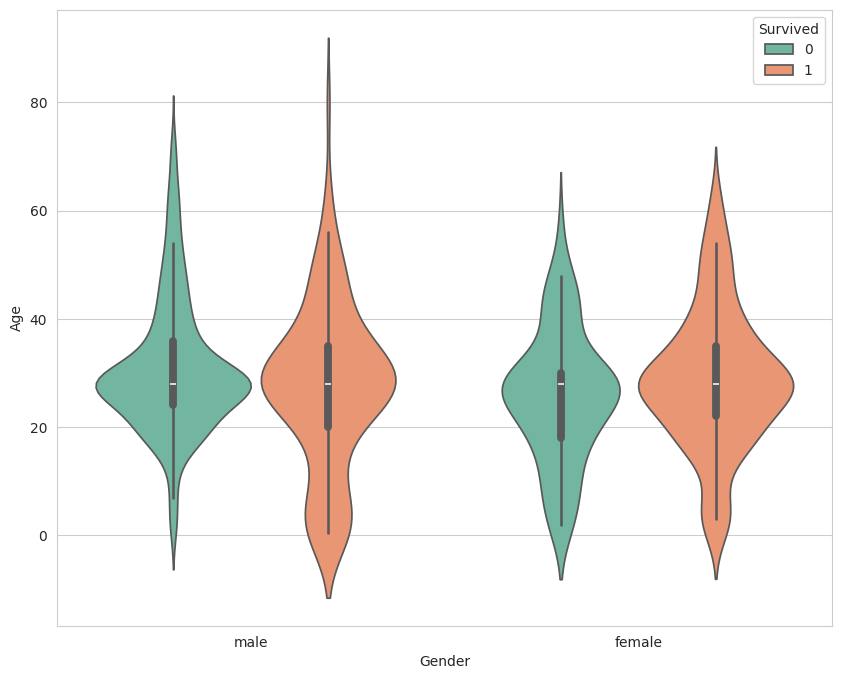

In [ ]:
#violin plot
plt.figure(figsize=(10,8))
sns.violinplot(data=df,x='Sex',y='Age',hue='Survived',palette='Set2')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

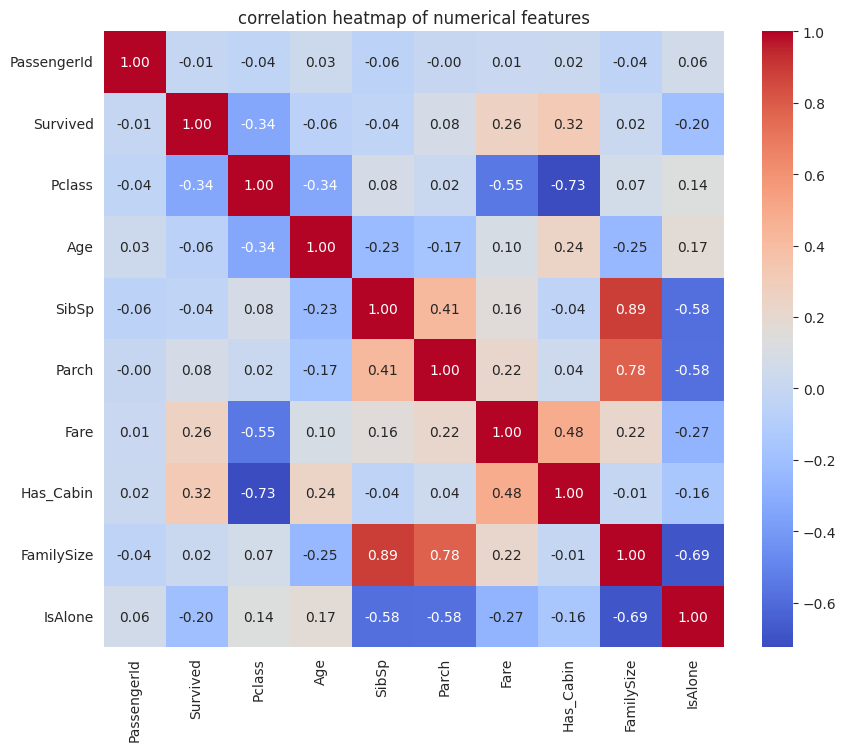

In [ ]:
#heatmap
plt.figure(figsize=(10,8))
numeric_cols=df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap of numerical features')
plt.show()